# 🐧 Machine Learning Homework: Classify the Penguins

Welcome. In the lectures you watched machine learning. Here you will do it yourself, on a small
and friendly set of data where you can see everything that happens.

We follow the same path that any data scientist follows:

> the data, then preparing the data, then running the algorithms, then judging the result

You will use, in the same order as the course, every method that you were taught:
Decision Tree, then SVM, then Gradient Descent, then Neural Network, then Evaluation.

### How to use this worksheet
* Some cells have blank spaces marked `___` and `# TODO`. Fill them in, then run the cell.
* Every task ends with a short footer:
  * ✅ **Check yourself:** what your result should look like, so you know it is correct.
  * 🔬 **Why it matters:** what this idea is used for in normal life. No special knowledge is needed.
  * 🎉 **Fun fact:** how this idea was used in one of the biggest moments in particle physics.
  * 💡 **Go further:** an extra challenge, if you want to push yourself.
* Keep the 🏆 Scoreboard near the end updated. Watch your models compete.

You do not need any physics or any earlier machine learning set up to do this (suggested to be done on goole collab). If you finish the ✅ tasks,
you have done the homework. The 💡 challenges are extra.


## Setup
Run this one time. Everything here is already available in Google Colab.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# A place to record each model score, so we can compare them at the end.
scoreboard = {}
print("Setup complete")

Setup complete


## Part 0. Meet the data 🔍  (about 5 min)

We use the Palmer Penguins data. It has body measurements of penguins from 3 species
(Adelie, Chinstrap, Gentoo). Our job is to predict the species from its body measurements.


In [2]:
penguins = sns.load_dataset("penguins")

# TODO: show the first 5 rows of the table
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64


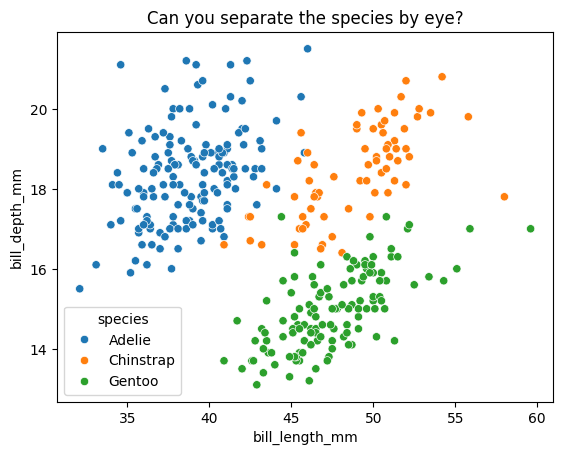

In [3]:
# How many penguins of each species do we have? This is what we want to predict.
print(penguins["species"].value_counts())

# TODO: draw a scatter plot of the two bill measurements, coloured by species
sns.scatterplot(data=penguins, x="bill_length_mm", y="bill_depth_mm", hue="species")
plt.title("Can you separate the species by eye?")
plt.show()

✅ **Check yourself:** you should see 344 penguins (about 152 Adelie, 124 Gentoo,
68 Chinstrap) and three colour clouds that overlap. That overlap is what makes this a real
problem, because no straight line can separate them perfectly.

🔬 **Why it matters:** looking at your data first is the habit that separates good analysts from
bad ones. It is true whether you are finding bank fraud, reading medical scans, or studying
particles. A model can only be as good as your understanding of what goes into it.

🎉 **Fun fact:** the biggest particle collider in the world, the Large Hadron Collider at CERN,
makes about one billion particle collisions every second. Scientists cannot save them all, so
the very first job is always to look at the data and decide what matters.

💡 **Go further:** which two species overlap the most? Which single measurement do you think best
separates the species? Write your guess, and you will be able to test it soon.


## Part 1. Prepare the data 🧹  (about 8 min)

Real data is messy. Before any algorithm we must handle missing values, pick our features (X)
and our target (y), and split the data into a training set and a test set. This preparation step
is where most of the real work in machine learning happens.


In [4]:
# Some measurements are missing. Count them first.
print("Missing values in each column:")
print(penguins.isna().sum())

# In the Decision Tree lecture we saw that scikit learn cannot use rows with missing values,
# so the simplest fix is to remove those rows.
# TODO: remove every row that has a missing value, then reset the index
data = penguins.dropna().reset_index(drop=True)
print("\nRows before:", len(penguins), "and after cleaning:", len(data))

Missing values in each column:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Rows before: 344 and after cleaning: 333


In [5]:
# Features (X) are the two bill measurements. The target (y) is the species.
features = ["bill_length_mm", "bill_depth_mm"]
X = data[features].values

# Models work with numbers, so we turn the species names into the numbers 0, 1 and 2.
species_names = sorted(data["species"].unique())
name_to_number = {name: i for i, name in enumerate(species_names)}
y = data["species"].map(name_to_number).values
print("Species to number:", name_to_number)

# TODO: split into 80 percent for training and 20 percent for testing.
#       Use random_state=42 so that everyone gets the same split.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print("Train:", X_train.shape, "and Test:", X_test.shape)

Species to number: {'Adelie': 0, 'Chinstrap': 1, 'Gentoo': 2}
Train: (266, 2) and Test: (67, 2)


✅ **Check yourself:** cleaning takes the data from 344 rows down to 333 rows. You should
have about 266 penguins for training and 67 for testing. The species map to
Adelie 0, Chinstrap 1, Gentoo 2.

🔬 **Why it matters:** choosing and cleaning features is the real science. Professionals often
spend more time preparing data than running the clever algorithms, because a model can only be as
good as the numbers you give it. The features you picked are the whole view of the world for the
model.

🎉 **Fun fact:** to study one tiny particle, physicists take many raw measurements and combine
them into a few smart numbers, called features. One of these numbers, the mass, is how they have
found brand new particles hiding inside the data.

💡 **Go further:** the data also has two more number columns (`flipper_length_mm` and
`body_mass_g`) and two text columns (`island` and `sex`). How would you turn the text column
`sex` into a number that a model can use?


## Part 2. Decision Tree 🌳  (about 7 min)

A decision tree asks a series of yes or no questions (for example, is the bill longer than
45 mm?) to sort each penguin. It is the simplest real classifier, and it is the easiest one to
understand.


In [6]:
# TODO: create a tree with max_depth=3, train it, then score it on the TEST set
tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X_train, y_train)

tree_acc = accuracy_score(y_test, tree.predict(X_test))
print(f"Decision Tree test accuracy: {tree_acc:.3f}")
scoreboard["Decision Tree"] = tree_acc

Decision Tree test accuracy: 0.910


✅ **Check yourself:** you should get about 0.91, which means about 91 out of every 100
penguins are correct. That is good for just a few yes or no questions.

🔬 **Why it matters:** decision trees are used everywhere. Banks use bigger versions of them to
decide who gets a loan, and hospitals use them to flag patients who may be at risk. The same
simple idea grows all the way up to the largest experiments in science.

🎉 **Fun fact:** a stronger version of the decision tree, called a boosted decision tree, helped
scientists at CERN find the Higgs boson in 2012. The Higgs boson helps explain why matter has
mass, and the discovery won a Nobel Prize.

💡 **Go further:** try every `max_depth` from 1 to 10 and draw a plot of test accuracy against
depth. It goes up, then flattens, and can even drop. That drop is called overfitting, where the
tree memorises the training penguins instead of learning the real pattern. Then try
`cross_val_score(tree, X, y, cv=5).mean()` for a more honest score.


## Part 3. Support Vector Machine ✂️  (about 8 min)

A support vector machine draws the widest possible boundary between the classes. It cares about
feature scaling. If one measurement uses much bigger numbers than another, it takes over unless
we rescale. Let us prove this with a small experiment.


In [7]:
# First without scaling:
svm_raw = SVC(kernel="rbf").fit(X_train, y_train)
acc_raw = accuracy_score(y_test, svm_raw.predict(X_test))

# Now with scaling. TODO: fit the scaler on the TRAIN set, then transform BOTH sets.
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)

svm = SVC(kernel="rbf").fit(X_train_s, y_train)
svm_acc = accuracy_score(y_test, svm.predict(X_test_s))

print(f"SVM without scaling: {acc_raw:.3f}")
print(f"SVM with scaling:    {svm_acc:.3f}")
scoreboard["SVM"] = svm_acc

SVM without scaling: 0.940
SVM with scaling:    0.970


✅ **Check yourself:** scaling should push the accuracy up, from about 0.94 to about 0.97.
The data and the model are the same. The only change is that we measured the features on a fair
scale.

🔬 **Why it matters:** scaling your features sounds boring, but forgetting it is one of the most
common reasons that real models quietly fail. It matters any time your measurements cover very
different ranges, for example a shopping website that mixes number of clicks with money spent.
The fix you just used is part of almost every serious project.

🎉 **Fun fact:** support vector machines have been used at particle colliders to find very rare
events, such as the top quark, which is the heaviest particle that we know. The machine had to
pick these rare events out of a huge pile of ordinary ones.

💡 **Go further:** build `X` again using all four number measurements and run this test once more.
The gap between scaled and not scaled becomes very large (about 0.69 up to 1.00). You can also
compare the linear kernel with the rbf kernel.


## Part 4. Gradient Descent 📉  (about 7 min)

So far, a single call to `.fit()` trained each model for you. But how does training actually work
inside? Almost always by gradient descent. You start somewhere, and then you take small steps
downhill to make the error smaller. Let us write that core idea in three lines, exactly as in the
lecture.


Start value is 5.0. After 25 steps theta is 0.0189. The target is 0.


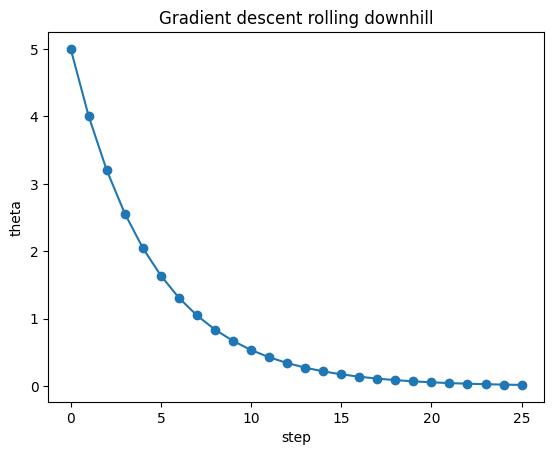

In [8]:
# A simple bowl shaped function that we want to make as small as possible, and its slope.
def f(theta):       return theta ** 2
def grad(theta):    return 2 * theta        # the slope of theta squared

theta = 5.0     # start far from the lowest point, which sits at 0
lr = 0.1        # learning rate is how big each downhill step is
path = [theta]

for step in range(25):
    # TODO: take one step downhill. Move theta against its slope.
    theta = theta - lr * grad(theta)    
    path.append(theta)

print(f"Start value is 5.0. After 25 steps theta is {theta:.4f}. The target is 0.")
plt.plot(path, marker="o"); plt.xlabel("step"); plt.ylabel("theta")
plt.title("Gradient descent rolling downhill"); plt.show()

✅ **Check yourself:** theta should slide from 5.0 down toward about 0.0 (about 0.02 after
25 steps), and the curve should look like a ball rolling into a valley. Try `lr = 0.9` (it jumps
around) or `lr = 0.01` (too slow to arrive).

🔬 **Why it matters:** gradient descent, moving numbers downhill to make the error smaller, is the
engine behind almost all modern artificial intelligence. The same three lines that you just wrote
are, deep down, how every large neural network learns, including the chat assistants that many
people use today.

🎉 **Fun fact:** gradient descent is how the learning models across physics are trained. This
includes the models that help physicists/researchers decide, in real time, which collisions to keep
and which ones to throw away.

💡 **Go further:** change the start value from 5.0 to a negative number. Does it still reach the
lowest point? What happens with a very big learning rate like `lr = 1.1`?


## Part 5. Neural Network 🧠  (about 10 min)

Now the star of the course. A neural network stacks simple parts together to learn curved
boundaries. We build a tiny one in PyTorch (already installed in Colab). It is trained by the
same gradient descent that you just met.


In [9]:
import torch
from torch import nn, optim

torch.manual_seed(0)

# Turn our scaled number arrays into torch tensors
Xtr = torch.tensor(X_train_s, dtype=torch.float32)
ytr = torch.tensor(y_train, dtype=torch.long)
Xte = torch.tensor(X_test_s, dtype=torch.float32)

# TODO: build a network with 2 inputs, then 16 hidden units with ReLU, then 3 outputs
model = nn.Sequential(
    nn.Linear(2, 16),
    nn.ReLU(),
    nn.Linear(16, 3),
)
print(model)

Sequential(
  (0): Linear(in_features=2, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=3, bias=True)
)


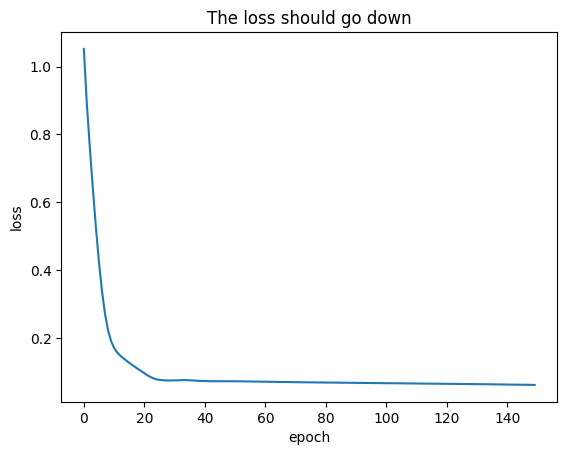

Neural Network test accuracy: 0.955


In [10]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.05)

# TODO: train for 150 rounds (epochs). In each round: clear the old slopes, predict,
#       measure the loss, go backward, then take one step.
losses = []
for epoch in range(150):
    optimizer.zero_grad()
    predictions = model(Xtr)
    loss = loss_fn(predictions, ytr)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

plt.plot(losses); plt.xlabel("epoch"); plt.ylabel("loss")
plt.title("The loss should go down"); plt.show()

nn_pred = model(Xte).argmax(dim=1).numpy()
nn_acc = accuracy_score(y_test, nn_pred)
print(f"Neural Network test accuracy: {nn_acc:.3f}")
scoreboard["Neural Network"] = nn_acc

✅ **Check yourself:** the loss curve should go down and settle at a low value. The test
accuracy should be around 0.95. If the loss stays flat or shows `nan`, check the learning rate.

🔬 **Why it matters:** you just built a neural network. To feel the size of this idea: networks
made from these same parts, only much bigger, power voice assistants, translation apps, and self
driving cars. And a small one, almost the same as yours, placed on a special chip, helps the
biggest physics experiment in the world look through 40 million events every second and decide,
in a few billionths of a second, what to keep.

🎉 **Fun fact:** neural networks help the IceCube experiment, a giant detector buried in the ice
of Antarctica, find ghostly particles called neutrinos. In 2017 this work led to a famous result.
A single neutrino was traced back to a galaxy far across the universe.

💡 **Go further:** add a second hidden layer, or change 16 to 4 and then to 64. More units make
the network more flexible, but watch for overfitting. Does the test accuracy really improve, or
only the training loss?


## Part 6. Judge the results ⚖️  (about 7 min)

Accuracy is a single number. A confusion matrix shows which species get mixed up. That is the
real story behind the number.


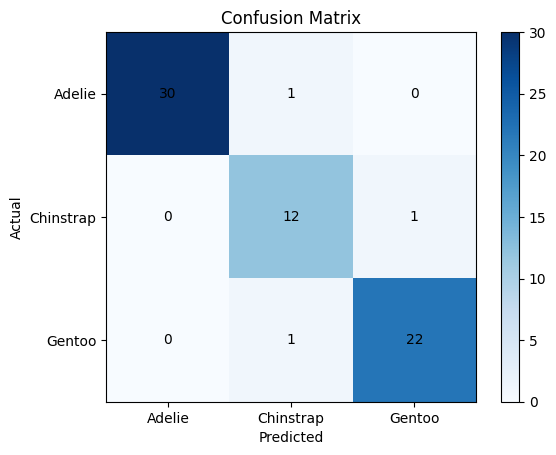

In [11]:
# TODO: build the confusion matrix that compares the true labels with the network predictions
cm = confusion_matrix(y_test, nn_pred)

plt.imshow(cm, cmap="Blues")
plt.xticks([0, 1, 2], species_names); plt.yticks([0, 1, 2], species_names)
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix")
for i in range(3):
    for j in range(3):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.colorbar(); plt.show()

In [12]:
# Scoreboard: every model on the same test set
print("SCOREBOARD")
for name, acc in sorted(scoreboard.items(), key=lambda kv: -kv[1]):
    print(f"   {name:22s} {acc:.3f}")

SCOREBOARD
   SVM                    0.970
   Neural Network         0.955
   Decision Tree          0.910


✅ **Check yourself:** the diagonal line (the correct predictions) should be much darker
than the rest. Most of the mix up is between the two species that overlapped in your scatter plot
in Part 0. Your scoreboard should show the models within a few percent of each other.

🔬 **Why it matters:** a single accuracy number can hide the truth. A medical test that is 99
percent accurate can still be dangerous if it misses the 1 percent of people who are truly sick.
So professionals always look at which mistakes a model makes, not only how many. Scientists are so
careful that, before they announce a discovery, they ask for proof so strong that it would happen
by pure luck less than 1 time in 3.5 million.

🎉 **Fun fact:** before scientists at CERN announced the Higgs boson, two separate teams each had
to reach this very strict level of proof, called five sigma. Only then did they trust that the new
particle was real and not a lucky accident.

💡 **Go further:** which model won on your run? Would it still win if you changed the
`random_state` in Part 1? Print `classification_report(y_test, nn_pred)` to see how well each
single species was predicted.


## 🎓 Very well done

You just built a complete machine learning pipeline from start to finish. You looked at raw data,
cleaned it, chose features, trained four different kinds of models, and judged them in an honest
way. This is the exact process that professionals use every day.

More importantly, you now understand what each method actually does, not only how to call it. That
understanding is the whole point of this exercise, and it is what makes the next and harder
problems feel possible.

The best way to make it stick is to go back and change things. Break the models on purpose. Every
time you ask what happens if I do this, you turn a fact that you memorised into an understanding
that you own.

Did you finish early and improve something? Clean notebooks can be added back to the course, with
your name credited. That is a nice thing to have to your name.
